In [1]:
import os
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
Distances = [10,20,30,40,50]
Times = [12,25,38,52,65]

df = pd.DataFrame({
        "Distances": Distances,
        "Times": Times
    })

In [3]:
X = df["Distances"].values.reshape(-1,1)
Y = df["Times"].values

In [4]:
#use Linear Regression
modelo = LinearRegression()

#transform
modelo.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Answer 1:

In [5]:
#print the values B1, B0 and R2
print("Pendiente (β₁):", modelo.coef_[0])
print("Intercepto (β₀):", modelo.intercept_)


Pendiente (β₁): 1.3300000000000003
Intercepto (β₀): -1.500000000000007


The relationship between distance and time can be modeled using a linear regression equation. The slope 1.33 indicates that for each aditional distance, time increases by 1.33 units on average. The intercept -1.5 represents the predicted time when sleep is zero.

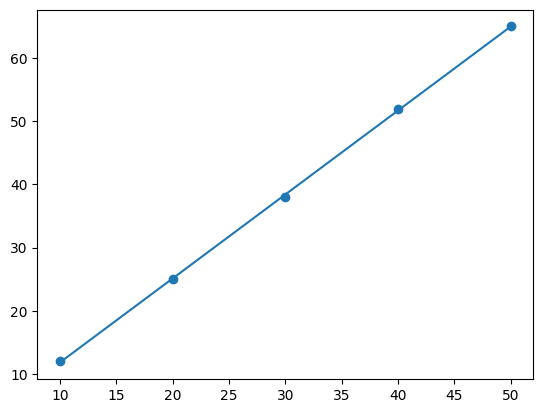

In [6]:
import matplotlib.pyplot as plt

#draw the graphical using linearRegression
plt.scatter(X, Y)
plt.plot(X, modelo.predict(X))
plt.show()

### Answer 2:

In [7]:
# Filtramos primero los datos de entrada
x2 = 35
y2 = modelo.coef_[0]*x2 + modelo.intercept_
print("Y:", y2)

Y: 45.050000000000004


When distance is 35, the will last is 45.05

### Answer 3:

In [8]:
X_mean = float(X.mean())
Y_mean = float(Y.mean())

In [9]:
X_mean

30.0

In [10]:
Y_mean

38.4

In [14]:
X_lessProm = X - X_mean
Y_lessProm = Y - Y_mean

X_lessProm2 = X_lessProm**2
Y_lessProm2 = Y_lessProm**2

In [15]:
X_lessProm

array([[-20.],
       [-10.],
       [  0.],
       [ 10.],
       [ 20.]])

In [16]:
Y_lessProm

array([-26.4, -13.4,  -0.4,  13.6,  26.6])

In [21]:
XY_lessProm = X_lessProm.T*Y_lessProm
XY_lessProm

array([[528., 134.,  -0., 136., 532.]])

In [22]:
Sxx = float(X_lessProm2.sum())
Syy = float(Y_lessProm2.sum())
Sxy = float(XY_lessProm.sum())
Syy

1769.1999999999998

In [23]:
Sxy

1330.0

In [24]:
RSyy = Syy**(1/2)
RSyy

42.06185920760041

Times are very dispersed

### Answer 4:

In [25]:
print("R²:", modelo.score(X, Y))

R²: 0.9998304318335971


Is aproximately 99,98%, so predictions are highly reliable, becase R2 are too high and residuals are very small

In [26]:
r2_manual= float((Sxy**2)/(Sxx*Syy))
r2_manual

0.9998304318335972

In [35]:
error_r2 = abs(r2_manual - modelo.score(X, Y))
error_r2

1.1102230246251565e-16

### Answer 5:

In [27]:
#predict values
Y_pred = modelo.predict(X)
df["y_pred"] = Y_pred
df["y_pred"]


0    11.8
1    25.1
2    38.4
3    51.7
4    65.0
Name: y_pred, dtype: float64

In [28]:
residuos = Y - Y_pred
df["residuos"] = residuos
df["residuos"]

0    0.2
1   -0.1
2   -0.4
3    0.3
4    0.0
Name: residuos, dtype: float64

In [29]:
df["residuos_sqr"] = df["residuos"]**2
df["residuos_sqr"]

0    0.04
1    0.01
2    0.16
3    0.09
4    0.00
Name: residuos_sqr, dtype: float64

In [30]:
MSE = float(df["residuos_sqr"].sum()/(df["residuos_sqr"].size))
MSE

0.05999999999999972

In [31]:
RMSE = float(MSE**(1/2))
RMSE

0.24494897427831724

Resudals values are very low, so values are so near zero, only fourth data is zero, RMSE is approximately 0.245, meaning that times derivates from the predcted trend by about 0.245 units on average.

In [32]:
o2 = float(df["residuos_sqr"].sum()/(df["residuos_sqr"].size - 2))
o2

0.09999999999999953

In [33]:
o = float(o2**(1/2))
o

0.3162277660168372

In [34]:
SE = o
SE

0.3162277660168372

The standard error is aproximately 0.316, which is relatively small. This indicates that the estimated relationship is stable and reliable.

In [ ]:
Nota, la pregunta 5 pide el error de la varianza

In [36]:
SEb = float(o/Sxx**(1/2))
SEb

0.009999999999999978

In [37]:
SEa = float(o*((1/df["residuos_sqr"].size)+(X_mean**2/Sxx))**(1/2))
SEa

0.33166247903553925